# Tutorial 32 — Tungsten: SCDM entanglement from atomic projectability

The waw-native reimagining of Wannier90 tutorial 32 -- bcc tungsten, 13 $s;p;d$-like MLWFs from **21 candidate bands**, built with SCDM's `erfc` entanglement function (tutorials 27/31), but where $\mu$/$\sigma$ are no longer hand-picked: they come from fitting the erfc form directly to a real *projectability* curve.

**Projectability** (QE's `projwfc.x`) is $|\langle \psi_{nk} | \hat P_{\rm atomic} | \psi_{nk} \rangle|^2$ -- how much of each DFT band $n,k$ overlaps the pseudopotential's own atomic orbitals. States with mostly atomic (bonding/$d$-manifold) character score near 1; free-electron-like high-energy states score near 0. Plotted against energy, this traces out almost exactly an `erfc` step -- so instead of guessing `scdm_mu`/`scdm_sigma` by eye (tutorials 27/31), this notebook **fits** them: new `waw.interfaces.quantum_espresso.projwfc.run_projwfc`/`read_projectability` run `projwfc.x` and parse its `proj.out` (reimplementing the real tutorial's own `generate_weights.sh` `grep`/`awk`/`sort` pipeline in Python), then `scipy.optimize.curve_fit` fits `0.5*erfc((E-mu)/sigma)` to the resulting scatter.

The real tutorial also sets `dis_num_iter=0`: the disentangled subspace is used **exactly as SCDM's initial guess gives it**, with NO further SMV01 iterative refinement (only the localization/spread minimization, `num_iter=10000`, still runs) -- the pedagogical point being that a well-fitted entanglement function already picks such a clean subspace that iterative disentanglement has nothing left to improve.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged bcc W, and a throwaway first SCDM pass
PseudoDojo scalar-relativistic W (no SOC needed -- unlike tutorials 29-31's Pt/GaAs), primitive bcc cell (ASE's own convention, conventional $a=3.1831$ Å, matching the real tutorial's explicit `CELL_PARAMETERS`), `ecutwfc=82` Ry (PseudoDojo's own "high" hint, 41 Ha -- confirmed by a direct SCF cutoff scan: total energy changes by only 0.1 mRy between 70 and 80 Ry). `nbnd=21` candidate bands, `num_wann=13`.

`projwfc.x` needs a **converged NSCF it can read wavefunctions from**, so we first run `generate_overlaps` once with a throwaway `scdm_entanglement='isolated'` (uniform weighting -- its own SCDM guess is discarded entirely, only the SCF/NSCF `out/` directory it leaves behind matters here).

In [2]:
from ase.build import bulk
from scipy.optimize import curve_fit
from scipy.special import erfc
from waw.interfaces.quantum_espresso.projwfc import run_projwfc, read_projectability
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands

atoms = bulk('W', 'bcc', a=3.1831145422)   # ASE's own primitive bcc cell, 1 atom
MP_GRID = (10, 10, 10)
NBND, NUM_WANN = 21, 13
WORK = HERE / 'runs' / 'tungsten'
SYSTEM_EXTRA = dict(occupations='smearing', smearing='mv', degauss=0.02)

ov0 = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'w',
    ecutwfc=82, scf_kpts=(14, 14, 14), nbnd=NBND, num_wann=NUM_WANN,
    scdm_entanglement='isolated',
    system_extra=SYSTEM_EXTRA, pseudopotentials={'W': 'W.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
)
print(f"E_F = {ov0['fermi_energy']:.4f} eV (throwaway pass, out/ now populated)")

E_F = 22.1940 eV (throwaway pass, out/ now populated)


### 2. `projwfc.x` projectability vs. energy, and the erfc fit
`run_projwfc` writes the `&projwfc` namelist and runs `projwfc.x` under `mpirun` (confirmed empirically parallel-safe on this cluster, unlike `wannier90.x`/`postw90.x`'s serial-only builds -- identical output at `-np 1` vs `-np 2`); `read_projectability` parses its `proj.out` into one `(energy, |psi|^2)` pair per (k-point, band).

21000 (k, band) pairs from projwfc.x
fit: scdm_mu = 31.1058 eV, scdm_sigma = 4.7187 eV, R^2 = 0.972395


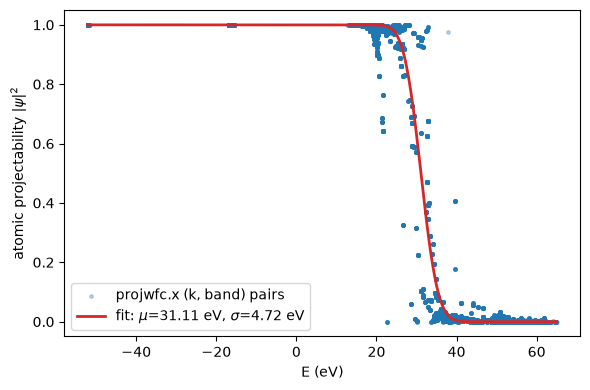

In [3]:
proj_out = run_projwfc(WORK, 'w', ncores=NCORES)
energies_eV, proj = read_projectability(proj_out)
print(f'{len(energies_eV)} (k, band) pairs from projwfc.x')

def erfc_model(e, mu, sigma):
    return 0.5 * erfc((e - mu) / sigma)

order = np.argsort(energies_eV)
e_sorted, p_sorted = energies_eV[order], proj[order]
popt, _ = curve_fit(erfc_model, e_sorted, p_sorted,
                     p0=[float(np.median(e_sorted)), 5.0], maxfev=20000)
mu_fit, sigma_fit = popt
resid = p_sorted - erfc_model(e_sorted, *popt)
r2 = 1.0 - np.sum(resid**2) / np.sum((p_sorted - p_sorted.mean())**2)
print(f'fit: scdm_mu = {mu_fit:.4f} eV, scdm_sigma = {sigma_fit:.4f} eV, R^2 = {r2:.6f}')

e_plot = np.linspace(e_sorted.min(), e_sorted.max(), 400)
plt.figure(figsize=(6, 4))
plt.scatter(energies_eV, proj, s=6, alpha=0.3, label='projwfc.x (k, band) pairs')
plt.plot(e_plot, erfc_model(e_plot, *popt), 'C3-', lw=2,
         label=f'fit: $\\mu$={mu_fit:.2f} eV, $\\sigma$={sigma_fit:.2f} eV')
plt.xlabel('E (eV)'); plt.ylabel('atomic projectability $|\\psi|^2$')
plt.legend(); plt.tight_layout(); plt.show()

### 3. The real SCDM pass: `erfc` entanglement with the fitted $\mu,\sigma$
Same DFT, `rerun_scf=False` reuses the completed SCF -- only the pw2wannier90/SCDM step changes, now with the fitted `scdm_mu`/`scdm_sigma`. Then `wannierize(..., dis_n_iter=0, n_iter=10000)`: the disentangled subspace is `V` exactly as SCDM's own initial projection gives it (see `core.disentangle.disentangle`'s `for sweep in range(n_iter)` -- `n_iter=0` skips the loop body entirely and returns that initial subspace unchanged, `converged=False` is therefore expected and not a bug), with only the localization/spread minimization iterating.

In [4]:
ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'w',
    ecutwfc=82, scf_kpts=(14, 14, 14), nbnd=NBND, num_wann=NUM_WANN,
    scdm_entanglement='erfc', scdm_mu=mu_fit, scdm_sigma=sigma_fit,
    system_extra=SYSTEM_EXTRA, pseudopotentials={'W': 'W.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
)
E_FERMI = ov['fermi_energy']

result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=NUM_WANN,
    dis_n_iter=0, n_iter=10000, conv_tol=8e-6, conv_window=3,
)
print(f'E_F = {E_FERMI:.4f} eV')
print(f'Omega_I     = {result.dis.omega_i * BOHR_TO_ANG**2:.6f} Ang^2')
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.6f} Ang^2')

[waw] nk=1000  nb=21  nw=13  nnb=12
[waw] Disentangling (zmatrix): nb=21 → nw=13 ...


[waw]   Omega_I = 55.091662 Bohr²  (not converged)
[waw] SVD init Omega = 134.1639 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...


[waw]   Omega = 98.568826 Bohr²  (I=55.0917, D=5.9330, OD=37.5441)  [converged]
[waw] H(R) built: nR=1115  mp_grid=(10, 10, 10)
E_F = 22.1940 eV
Omega_I     = 15.427237 Ang^2
Omega_total = 27.602083 Ang^2


### 4. Interpolated band structure
Same ASE-standard bcc k-path convention as every other notebook (`band_path`, Setyawan-Curtarolo: $\Gamma$-H-N-$\Gamma$-P-H,P-N).

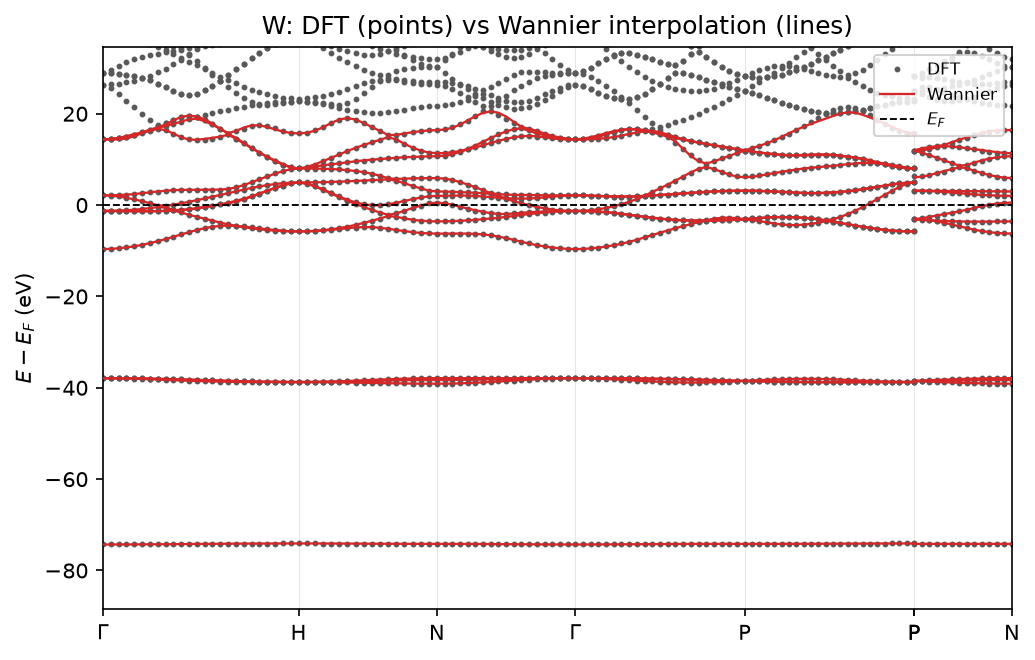

on the Wannier mesh, inside the frozen window: max 1467.538 meV, rms 45.174 meV over 13000 states


In [5]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'w', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('W: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** Fitting the erfc entanglement function to a real, computed atomic-projectability curve -- rather than hand-picking `scdm_mu`/`scdm_sigma` (tutorials 27/31) -- already selects such a clean initial subspace that `dis_num_iter=0` (no iterative disentanglement refinement at all) reproduces real `wannier90.x`'s own bcc W bands; see `project_waw.md`'s tutorial32 entry for the cross-validation record.